# 0. import

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
# this notebook lives in plot_revision/scripts/, so plot_revision/ is its parent
_HERE = Path.cwd().resolve()
# tolerate cwd being either plot_revision/scripts or plot_revision or the repo root
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR,
 CLAUDE_CLADE_DIR, TREE_NWK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [30]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.lines import Line2D

from importlib import reload
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.patches as patches

from plot_settings import *

from scipy.stats import gaussian_kde, spearmanr
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')


In [31]:
chromosomes = {
    'human': [9,10],
    'mouse': [1,2,3,4]
}

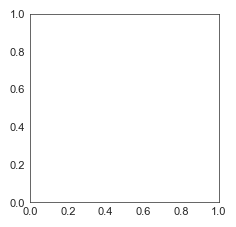

In [32]:
fig = plt.figure(figsize=(8.27, 3))

gs = gridspec.GridSpec(
    1, 3,  
    figure=fig,
    hspace=0.0,
    width_ratios=[1, 1, 1]
)

axes = []
for i, row in enumerate([0]):
    row_axes = []
    for j in [1]:
        ax = fig.add_subplot(gs[row, j])
        row_axes.append(ax)
    axes.append(row_axes)

axes = np.array(axes)
for ax in axes.flatten():
    ax.set_aspect('equal')
    # ax.axis('off')
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)


In [33]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 4. Inference cost

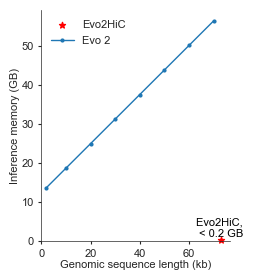

In [34]:
context_evo2 = np.array([2, 10, 20, 30, 40, 50, 60, 70])
time_evo2 = np.array([0.22, 1.13, 2.48, 3.83, 5.42, 6.70, 8.76, 9.98])
memory_evo2 = np.array([13.58193588256836, 18.61448383331299, 24.901814460754395, 31.1879243850708, 37.47877216339111, 43.76596260070801, 50.05349159240723, 56.34082221984863])

context_cnn = 73.016
time_cnn = 0.02
memory_cnn = 0.1968684196472168

ax = axes[0][0]
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.clear()
ax.set_aspect('auto')

ax.scatter(context_cnn, memory_cnn, marker='*', s=20, color='red', label='Evo2HiC', clip_on=False)  # 五角星
ax.plot(context_evo2, memory_evo2, 'o-', label='Evo 2', linewidth=1, ms=2)
ax.text(context_cnn, memory_cnn+0.25, 'Evo2HiC, \n< 0.2 GB', color='black',
         ha='center', va='bottom', fontsize='medium')

sns.despine(ax=ax)

ax.set_xlabel('Genomic sequence length (kb)')
ax.set_ylabel('Inference memory (GB)')
ax.xaxis.labelpad = 1
ax.yaxis.labelpad = 1
ax.legend(loc='upper left')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xticks(np.arange(0, 73, 20))
ax.tick_params(axis='both', length=2)
fig


# Final

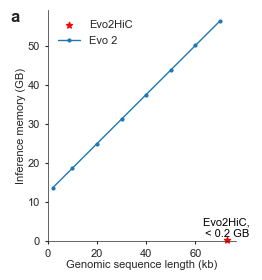

In [35]:
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i','j']
axs = [axes[0][0]]

for ax, label in zip(axs, labels):
    ax.text(
        -0.2, 1.0, f'{label}',           # 相对位置：左上角内一点
        transform=ax.transAxes, 
        fontsize=12,
        fontname='Arial',               # 字体
        fontweight='bold',                  # 粗体 (Nature风格)
        ha='left', va='top'                 # 对齐方式
    )
fig

In [36]:
fig.savefig(str(OUT_DIR / 'supplementary_2.pdf'), dpi=300)